In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_paper/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
# %matplotlib widget

In [2]:
def load_cycling_data_ch(cell,eSOH_DIR,oCV_DIR,cyc_DIR,cyc_no):
    cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
    cycles = np.array(dfe_0['N'].astype('int'))+1
    print(cell_no)
    cyc_data_raw1 = pd.read_csv(cyc_DIR+'cycling_data_cell_'+cell_no+'.csv')
    N1 = cycles[cyc_no]
    print(N1)
    cyc_data_raw = cyc_data_raw1[ cyc_data_raw1['Cycle number'] == N1 ]
    cyc_data = cyc_data_raw.reset_index(drop=True)
    t_c1 = cyc_data['Time [s]']-cyc_data['Time [s]'][0]
    t_c1 = t_c1.values
    I_c1 = cyc_data['Current [mA]']/1000
    I_c1 = I_c1.values
    V_c1 = cyc_data['Voltage [V]']
    V_c1 = V_c1.values
    E_c1 = cyc_data["Expansion [mu m]"]
    E_c1 = E_c1.values
    # idx_I = np.where(np.sign(I_c1[:-1]) != np.sign(I_c1[1:]))[0] 
    # idx_I = idx_I[idx_I>50]
    idx_I = np.where(np.diff(I_c1) < -0.1)[0] 
    t = t_c1[:idx_I[0]]
    V = V_c1[:idx_I[0]]
    I = I_c1[:idx_I[0]]
    E = E_c1[:idx_I[0]]-E_c1[0]
    Q = integrate.cumtrapz(I,t, initial=0)/3600 #Ah
    
    return t,V,I,Q,E


In [3]:
spm = pybamm.lithium_ion.SPM(
    {
        "stress-induced diffusion": "false",
    }
)
param=spm.param
parameter_values = get_parameter_values()

In [4]:
def model_error(data_time,data_current,data_voltage,parameter_values,SOC_0=0,plot_bool=False):
    # t_int = np.arange(0,data_time[-1],1)
    t_int = data_time
    f_I_int = interpolate.interp1d(data_time,-data_current)
    f_V_int = interpolate.interp1d(data_time,data_voltage)

    I_int = f_I_int(t_int)
    V_int = f_V_int(t_int)
    timescale = parameter_values.evaluate(spm.timescale)
    current_interpolant = pybamm.Interpolant(
    #  drive_cycle[:, 0], drive_cycle[:, 1], timescale * pybamm.t
    t_int, I_int, timescale * pybamm.t
    )

    pybamm.set_logging_level("NOTICE")
    parameter_values["Current function [A]"] = current_interpolant
    # var_pts=var_pts,
    sim = pybamm.Simulation(spm, 
                            parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver(
                                mode="safe", 
                                rtol=1e-6, 
                                atol=1e-6,
                                dt_max=10,
                                )
                            )
    # sim.solve(initial_soc = SOC_0)
    sim.solve(t_eval=t_int,initial_soc = SOC_0)
    solution = sim.solution
    t = solution["Time [s]"].entries
    V_sim = solution["Terminal voltage [V]"].entries
    I_sim = solution["Current [A]"].entries
    # Q = -solution['Discharge capacity [A.h]'].entries
    # f_I_sim = interpolate.interp1d(t,I,bounds_error=False,fill_value="extrapolate")
    # f_V_sim = interpolate.interp1d(t,V,bounds_error=False,fill_value="extrapolate")
    # I_sim = f_I_sim(t_int)
    # V_sim = f_V_sim(t_int)
    I_int = f_I_int(t)
    V_int = f_V_int(t)
    rmse = pybamm.rmse(V_int,V_sim)
    if plot_bool:
        fig, ax1 = plt.subplots(1, 1, figsize=(5, 4), sharex=True)
        ax1.plot(t, V_int, 'k')
        ax1.plot(t, V_sim, 'b--')
        ax1.text(0.7,0.2,f'RMSE: {rmse*1e3:0.1f} mV',transform=ax1.transAxes)
        # ax1.plot(t1, V1, 'r-.')
        ax1.set_ylabel("Voltage [V]")
        # ax1.set_title("Cell 01 Fresh HPPC")
        ax1.set_ylim([3,4.21])
        ax1.set_xlabel("Time [s]")
        # ax1.set_xlim([20370,20470])
        ax1.legend(['data','sim'])
        fig.tight_layout()
        plt.show()
        # fig.savefig(fig_DIR+str(int(10000*random.random()))+".png")
    return rmse

In [5]:
t_c5,V_c5,I_c5,Q_c5,E_c5 = load_cycling_data_ch(2,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t_1p5c,V_1p5c,I_1p5c,Q_1p5c,E_1p5c = load_cycling_data_ch(5,eSOH_DIR,oCV_DIR,cyc_DIR,0)
t_2c,V_2c,I_2c,Q_2c,E_2c = load_cycling_data_ch(8,eSOH_DIR,oCV_DIR,cyc_DIR,0)

02
1
05
1
08
1


In [6]:
T = 273.15-5
E_r = 39570.0
R = 8.314
np.exp(E_r / R * (1 / 298.15 - 1 / T))

0.16764091872841894

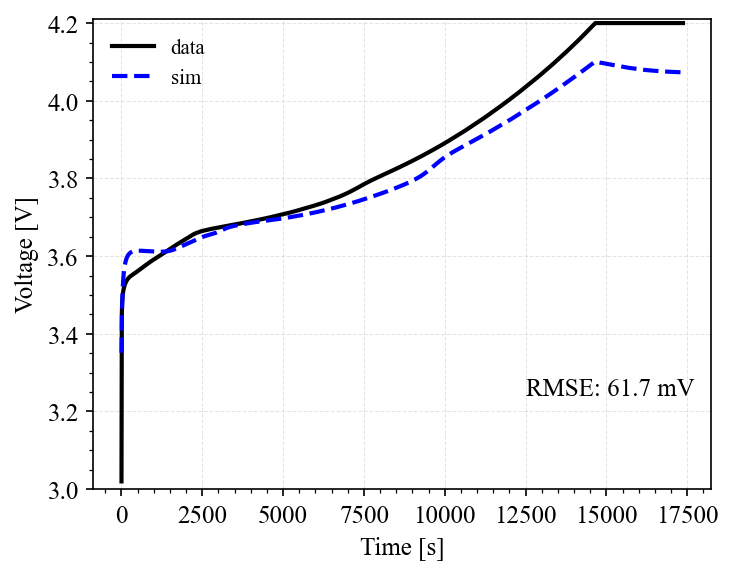

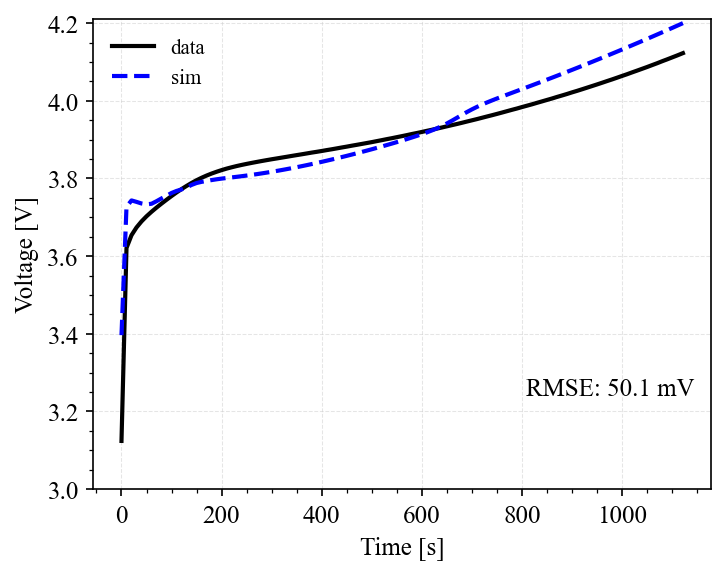

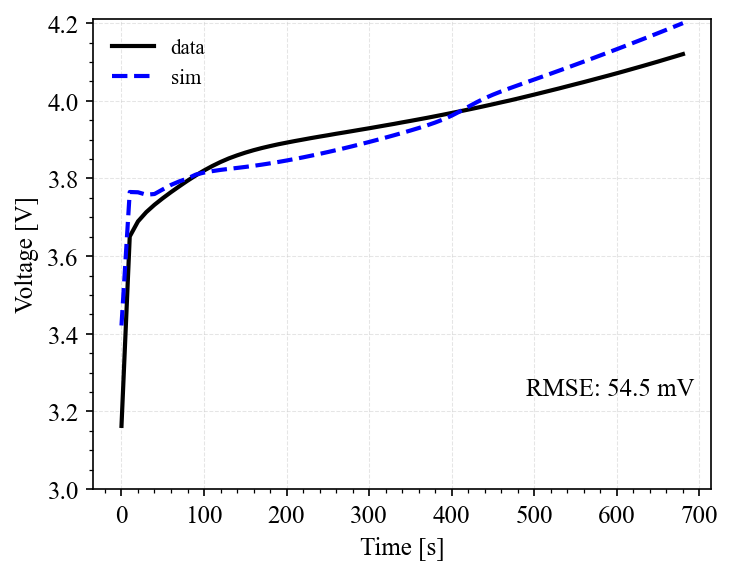

In [17]:
cell = 5
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe_0,spm,parameter_values)
parameter_values = get_parameter_values()
def update_parameters(x):
    parameter_values = get_parameter_values()
    parameter_values.update(
        {
            "Negative electrode active material volume fraction": eps_n_data,
            "Positive electrode active material volume fraction": eps_p_data,
            "Initial temperature [K]": 273.15+Temp,
            "Ambient temperature [K]": 273.15+Temp,
            "Initial inner SEI thickness [m]": 0e-09,
            "Initial outer SEI thickness [m]": 5e-09,
            "SEI resistivity [Ohm.m]": 30000.0,
        },
        check_already_exists=False,
    )
    parameter_values.update(
        {
            "Positive electrode diffusion coefficient activation energy [J.mol-1]": x[0]*10000.0*0,
            "Negative electrode diffusion coefficient activation energy [J.mol-1]": x[1]*10000.0*0,
            "Positive electrode reference exchange-current density activation energy [J.mol-1]": x[2]*10000.0*0,
            "Negative electrode reference exchange-current density activation energy [J.mol-1]": x[3]*10000.0*0,
            
            "Positive electrode diffusion coefficient [m2.s-1]": x[0]*7e-16,# *0.93,
            "Negative electrode diffusion coefficient [m2.s-1]": x[1]*7e-15,# *30.2,
            "Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]": x[2]*0.9e-06,#*3.3,
            "Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]":	x[3]*0.9e-06,#*0.62,
            
            # "Positive electrode OCP entropic change [V.K-1]": 0,
            # "Negative electrode OCP entropic change [V.K-1]": 0,
        },
        check_already_exists=False,
    )
    return parameter_values
x = np.array([1.0,1.0,1.0,1.0])
parameter_values = update_parameters(x)
plot_bool = True
rmse1 = model_error(t_c5,I_c5,V_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool)
rmse2 = model_error(t_1p5c,I_1p5c,V_1p5c,parameter_values,SOC_0=0,plot_bool=plot_bool)
rmse3 = model_error(t_2c,I_2c,V_2c,parameter_values,SOC_0=0,plot_bool=plot_bool)

In [32]:
def prediction_error(x):
    try:
        parameter_values = update_parameters(x)
        rmse1 = model_error(t_c5,I_c5,V_c5,parameter_values,SOC_0=0.005,plot_bool=False)
        rmse2 = model_error(t_1p5c,I_1p5c,V_1p5c,parameter_values,SOC_0=0,plot_bool=False)
        rmse3 = model_error(t_2c,I_2c,V_2c,parameter_values,SOC_0=0,plot_bool=False)
        # rmse5 = model_error(t_d1_hppc,I_d1_hppc,V_d1_hppc,parameter_values,SOC_0=1,plot_bool=False)
        out = rmse1 + rmse2 + rmse3 
        out = np.array([out])
        # out = rmse1 
        print(f"x={x}, norm={np.linalg.norm(out)}")
    # except pybamm.SolverError:
    except Exception as error:
        out = 5
        out = np.array([out])
        print(f"x={x}, norm={np.linalg.norm(out)}")
        print(error)
        return out
    return out
def train_model():
    timer = pybamm.Timer()
    x0 = np.array([1.0,1.0,1.5,1.5])
    lower = np.array([1e-1, 1e-1, 1e-1, 1e-1])
    upper = np.array([1e+1, 1e+1, 1e+1, 1e+1])
    dfo_opts = {
        "init.random_initial_directions":True,
        "init.run_in_parallel": True,
    }
    soln_dfols = dfols.solve(prediction_error, x0,bounds=(lower, upper), rhoend=1e-4, user_params=dfo_opts)
    # soln_dfols = dfols.solve(prediction_error, x0, rhoend=1e-3, user_params=dfo_opts)
    print(timer.time())
    return soln_dfols

In [33]:
soln_dfols = train_model()
xsol = soln_dfols.x

x=[1.  1.  1.5 1.5], norm=0.16840924205327581
x=[0.87600172 1.02821643 1.43377614 1.45592437], norm=0.1772823132621399
x=[0.97242078 0.93840616 1.44430756 1.6218357 ], norm=0.17015089530788785
x=[1.0795684  1.01305323 1.37747379 1.46860238], norm=0.1667228994057792
x=[1.00571704 1.13319026 1.5002827  1.56875748], norm=0.17063977928260676
x=[1.21371776 0.9688725  1.42790809 1.46570507], norm=0.17981857508847932
x=[1.02442797 1.02144392 1.34156765 1.4336041 ], norm=0.16532019939589604
x=[1.01635478 1.09136511 1.33261263 1.45790755], norm=0.16631785522799625
x=[1.03100656 1.0299073  1.35148461 1.41509427], norm=0.1650206364670154
x=[1.02654294 1.02092292 1.33841254 1.38140855], norm=0.16436789635645532
x=[1.00141882 1.01249621 1.35467669 1.36044438], norm=0.16519411334810008
x=[1.03903707 1.01860573 1.33245744 1.37611099], norm=0.16388827562151106
x=[1.09093159 1.00790596 1.31368974 1.35512891], norm=0.1631134112661592
x=[1.0903641  1.05063957 1.27376903 1.34171798], norm=0.16258538499710

In [34]:
def plot_fit(x,plot_bool = True):
    parameter_values = update_parameters(x)
    print("RMSE")
    rmse = model_error(t_c5,I_c5,V_c5,parameter_values,SOC_0=0.005,plot_bool=plot_bool)
    print(f"C/5: {rmse}")
    rmse = model_error(t_1p5c,I_1p5c,V_1p5c,parameter_values,SOC_0=0,plot_bool=plot_bool)
    print(f"1.5C: {rmse}")
    rmse = model_error(t_2c,I_2c,V_2c,parameter_values,SOC_0=0,plot_bool=plot_bool)
    print(f"2C: {rmse}")

In [35]:
xsol

array([1.29860804, 1.1195382 , 1.21814073, 0.53329063])

In [36]:
# # Ds, i0
# xsol = [1.12912078, 1.01642996, 0.70840774, 0.2680896]
# # Activation energies
# xsol = [-0.27280449, 13.43951307,  4.70920307, -1.83341506]

RMSE


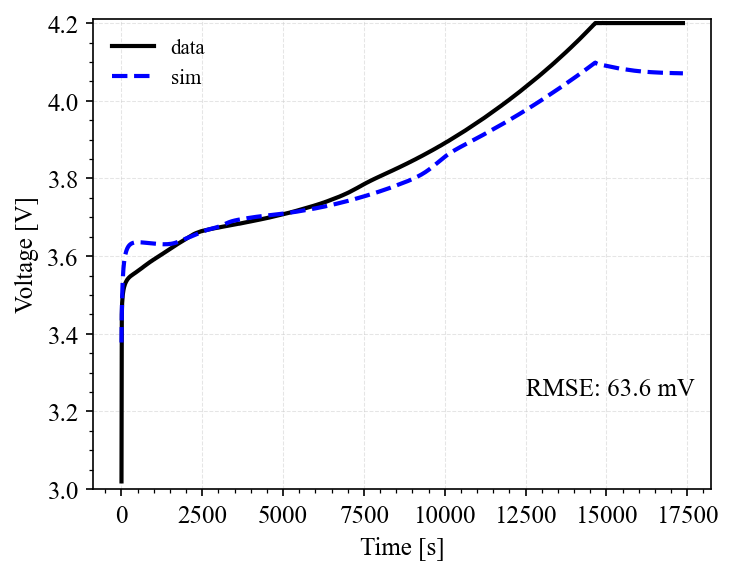

C/5: 0.06355815940438234


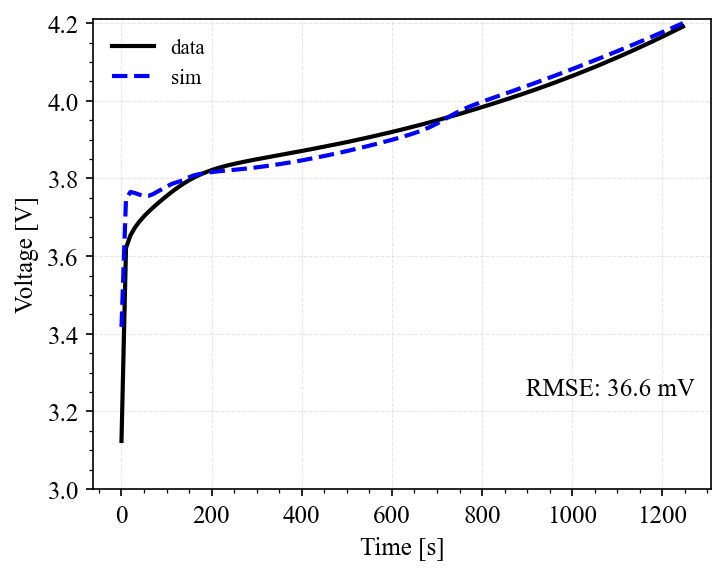

1.5C: 0.036621121713983594


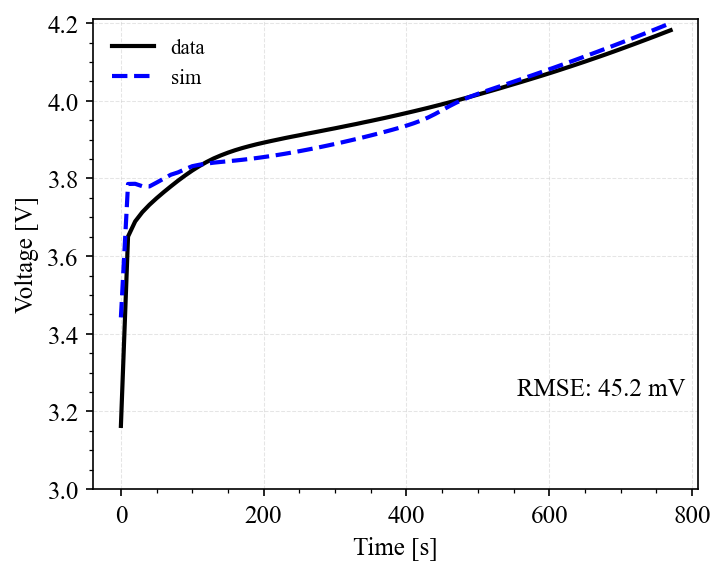

2C: 0.045168928918895644


In [37]:
plot_fit(xsol)

In [38]:
winsound.Beep(440, 2000)